# 📱 Klasifikasi Teks: Deteksi Spam SMS dengan Machine Learning
## Tugas Natural Language Processing (NLP)
---
| Info | Detail |
|------|--------|
| **Nama** | [Nama Mahasiswa] |
| **NIM** | [NIM] |
| **Kelas** | [Kelas/Prodi] |
| **Tanggal** | [Tanggal Pengumpulan] |
| **Repository GitHub** | [🔗 Link Repository GitHub] |

> **Artikel Referensi:** Airlangga, G. (2024). *Optimizing SMS Spam Detection Using Machine Learning: A Comparative Analysis of Ensemble and Traditional Classifiers.* Journal of Computer Networks, Architecture and High Performance Computing (CNAHPC), 6(4), 1942–1951. [Open Access — https://doi.org/10.47709/cnahpc.v6i4.4822](https://doi.org/10.47709/cnahpc.v6i4.4822)

---
## 📰 Bagian 0: Identifikasi Masalah dari Artikel

### Artikel Referensi

| Atribut | Detail |
|---------|--------|
| **Judul** | Optimizing SMS Spam Detection Using Machine Learning: A Comparative Analysis of Ensemble and Traditional Classifiers |
| **Penulis** | Gregorius Airlangga |
| **Jurnal** | Journal of Computer Networks, Architecture and High Performance Computing (CNAHPC) |
| **Volume/Edisi** | Vol. 6, No. 4, hal. 1942–1951, Oktober 2024 |
| **DOI** | https://doi.org/10.47709/cnahpc.v6i4.4822 |
| **Akses** | ✅ Open Access (dapat diakses gratis) |
| **Dataset** | SMS Spam Collection — 5.572 pesan SMS (spam & ham) |

---

### 🔍 Isu Masalah yang Diangkat

Berdasarkan artikel tersebut, **pesan SMS spam** merupakan ancaman yang terus berkembang dalam ekosistem komunikasi digital. Pesan spam tidak hanya mengganggu kenyamanan pengguna, tetapi juga menjadi sarana penipuan (*phishing*), penyebaran malware, dan kejahatan siber. Volume pesan spam terus meningkat seiring pertumbuhan pengguna *smartphone* global, termasuk di Indonesia.

Tantangan utama yang diidentifikasi artikel:
1. **Tingkat *false positive* yang tinggi** — pesan legitimate diklasifikasikan sebagai spam, merugikan pengguna.
2. **Variasi bahasa dan konten** — pesan spam terus berevolusi untuk menghindari sistem filter.
3. **Kebutuhan model efisien** — perlu model ringan yang bisa berjalan di perangkat mobile dengan resource terbatas.

---

### 💡 Solusi Klasifikasi Teks yang Dibangun

**Tujuan:** Membangun sistem otomatis yang dapat membedakan pesan SMS *spam* dari *ham* (pesan sah) menggunakan pendekatan **klasifikasi teks berbasis supervised learning**.

**Pipeline Solusi:**
```
Teks SMS Mentah → Praproses → Ekstraksi Fitur (TF-IDF/W2V) → Klasifikasi → Evaluasi
```

**Model yang Diuji:** Naive Bayes · Support Vector Machine (SVM) · Logistic Regression

**Dataset:** SMS Spam Collection Dataset (UCI Machine Learning Repository, 5.574 pesan)

---
## 📂 Bagian 1: Pengumpulan Data

### Deskripsi Dataset

| Atribut | Detail |
|---------|--------|
| **Nama** | SMS Spam Collection Dataset |
| **Sumber** | UCI Machine Learning Repository |
| **Penulis Dataset** | Almeida, Gómez Hidalgo & Yamakami (2011) |
| **URL Sumber** | https://archive.ics.uci.edu/ml/datasets/sms+spam+collection |
| **Mirror** | https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv |
| **Format** | Tab-Separated Values (.tsv) |
| **Lisensi** | Public Domain |

### Fitur Dataset

| Kolom | Tipe | Deskripsi |
|-------|------|-----------|
| `label` | Kategorikal | Kategori pesan: `ham` (bukan spam) atau `spam` |
| `message` | Teks | Isi teks pesan SMS |

### Informasi Sampel
- **Total Sampel:** 5.572 pesan SMS
- **Ham (sah):** 4.825 pesan (86,6%)
- **Spam:** 747 pesan (13,4%)
- **Bahasa:** Inggris

In [2]:
# ============================================================
# INSTALASI LIBRARY (jalankan jika belum terinstal)
# ============================================================
# !pip install wordcloud gensim nltk pandas scikit-learn matplotlib seaborn -q

# ============================================================
# IMPORT SEMUA LIBRARY
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLTK — Natural Language Toolkit
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Gensim — Word2Vec
from gensim.models import Word2Vec

# Scikit-learn — Feature Engineering & Classification
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

# WordCloud
from wordcloud import WordCloud

# Konfigurasi plot
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("✅ Semua library berhasil diimpor!")
print(f"   pandas   : {pd.__version__}")
print(f"   numpy    : {np.__version__}")
print(f"   sklearn  : selesai")
print(f"   gensim   : selesai")
print(f"   wordcloud: selesai")

✅ Semua library berhasil diimpor!
   pandas   : 2.3.3
   numpy    : 2.0.1
   sklearn  : selesai
   gensim   : selesai
   wordcloud: selesai


In [3]:
# ============================================================
# BAGIAN 1: LOAD DATASET DARI URL
# ============================================================

# URL dataset (mirror open-access dari UCI ML Repository)
DATASET_URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Muat dataset ke pandas DataFrame
df = pd.read_csv(DATASET_URL, sep='\t', header=None, names=['label', 'message'])

print("=" * 55)
print("  RINGKASAN DATASET SMS SPAM COLLECTION")
print("=" * 55)
print(f"\n✅ Dataset berhasil dimuat dari:\n   {DATASET_URL}")
print(f"\n📊 Dimensi Dataset : {df.shape[0]:,} baris × {df.shape[1]} kolom")
print(f"\n📌 Tipe Data:")
print(df.dtypes.to_string())
print(f"\n📌 Nilai Kosong (Missing Values):")
print(df.isnull().sum().to_string())

print(f"\n📌 Distribusi Label:")
vc = df['label'].value_counts()
pct = df['label'].value_counts(normalize=True) * 100
for lbl in vc.index:
    bar = '█' * int(pct[lbl] / 2)
    print(f"   {lbl.upper():4s}: {vc[lbl]:,} pesan ({pct[lbl]:.1f}%)  {bar}")

print(f"\n📌 Contoh Data (5 baris pertama):")
display(df.head())

  RINGKASAN DATASET SMS SPAM COLLECTION

✅ Dataset berhasil dimuat dari:
   https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv

📊 Dimensi Dataset : 5,572 baris × 2 kolom

📌 Tipe Data:
label      object
message    object

📌 Nilai Kosong (Missing Values):
label      0
message    0

📌 Distribusi Label:
   HAM : 4,825 pesan (86.6%)  ███████████████████████████████████████████
   SPAM: 747 pesan (13.4%)  ██████

📌 Contoh Data (5 baris pertama):


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


📊 Statistik Panjang Teks (Teks Asli):

      msg_length                                                  word_count                                             unique_words                                           
           count    mean    std   min    25%    50%    75%    max      count   mean    std  min   25%   50%   75%    max        count   mean   std  min   25%   50%   75%    max
label                                                                                                                                                                           
ham       4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0     4825.0  14.31  11.52  1.0   7.0  11.0  19.0  171.0       4825.0  13.13  9.15  1.0   7.0  10.0  18.0  100.0
spam       747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0      747.0  23.91   5.78  2.0  22.0  25.0  28.0   35.0        747.0  22.47  5.25  2.0  20.0  24.0  26.0   33.0


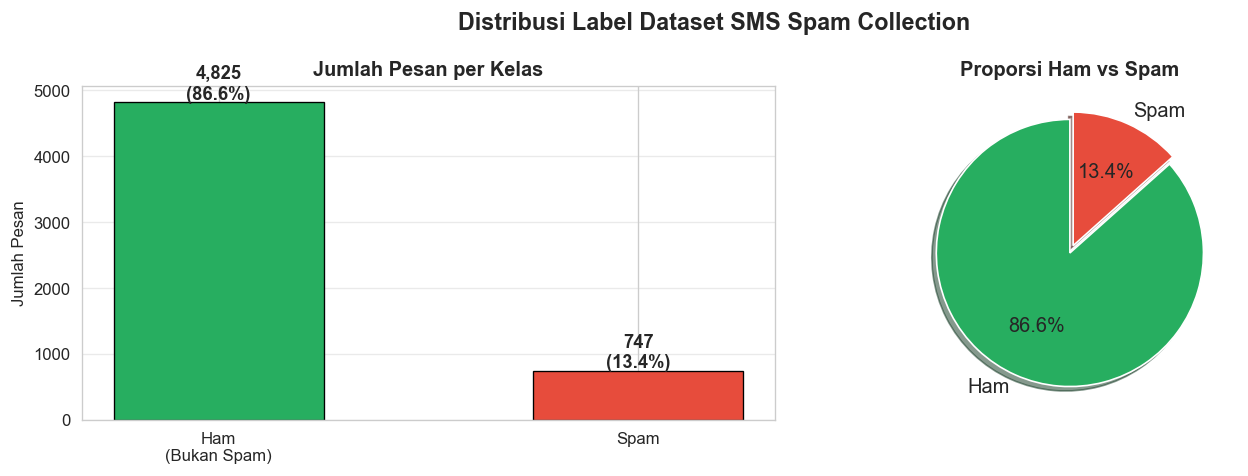


✅ Visualisasi distribusi label selesai.


In [4]:
# ============================================================
# STATISTIK DESKRIPTIF DATASET
# ============================================================

# Tambahkan kolom statistik teks
df['msg_length']   = df['message'].apply(len)
df['word_count']   = df['message'].apply(lambda x: len(x.split()))
df['char_count']   = df['message'].apply(lambda x: len(x.replace(' ', '')))
df['unique_words'] = df['message'].apply(lambda x: len(set(x.lower().split())))

print("📊 Statistik Panjang Teks (Teks Asli):\n")
stats = df.groupby('label')[['msg_length', 'word_count', 'unique_words']].describe()
stats.columns = ['_'.join(col).strip() for col in stats.columns]
print(df.groupby('label')[['msg_length', 'word_count', 'unique_words']].describe().round(2).to_string())

# Visualisasi distribusi label
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Distribusi Label Dataset SMS Spam Collection', fontsize=14, fontweight='bold')

colors = ['#27ae60', '#e74c3c']
label_counts = df['label'].value_counts()

# Bar chart
bars = axes[0].bar(['Ham\n(Bukan Spam)', 'Spam'], label_counts.values,
                    color=colors, edgecolor='black', linewidth=0.8, width=0.5)
axes[0].set_title('Jumlah Pesan per Kelas', fontweight='bold')
axes[0].set_ylabel('Jumlah Pesan')
axes[0].grid(axis='y', alpha=0.4)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(label_counts.values, labels=['Ham', 'Spam'], colors=colors,
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12},
            explode=(0, 0.06), shadow=True)
axes[1].set_title('Proporsi Ham vs Spam', fontweight='bold')

plt.tight_layout()
plt.savefig('distribusi_label.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Visualisasi distribusi label selesai.")

---
## 🧹 Bagian 2: Pra-Pemrosesan Teks (Text Pre-processing)

Pipeline pra-pemrosesan yang diterapkan secara berurutan:

| # | Langkah | Deskripsi |
|---|---------|-----------|
| 1 | **Lowercasing** | Mengubah semua huruf menjadi lowercase untuk konsistensi |
| 2 | **Hapus URL & Angka** | Menghilangkan URL, nomor telepon, dan angka |
| 3 | **Hapus Tanda Baca & Karakter Khusus** | Menghilangkan noise non-alfabet |
| 4 | **Tokenisasi** | Memecah teks menjadi unit kata (token) individu |
| 5 | **Hapus Stopwords** | Menghilangkan kata umum tak bermakna (the, is, and, ...) |
| 6 | **Stemming** | Mereduksi kata ke bentuk dasar (Porter Stemmer) |

In [5]:
# ============================================================
# BAGIAN 2: PRA-PEMROSESAN TEKS
# ============================================================

# --- Inisialisasi tools ---
stemmer    = PorterStemmer()
stop_words = set(stopwords.words('english'))

# Tambahan stopwords informal SMS
stop_words.update({'u', 'ur', 'im', 'r', 'ok', 'ya', 'yea', 'tht', 'hav',
                   'wat', 'wil', 'gud', 'pls', 'plz', 'dont', 'thats', 'gt',
                   'lt', 'amp', 'nbsp'})

def preprocess_text(text):
    '''
    Pipeline pra-pemrosesan teks lengkap.
    Steps: lowercase → hapus URL/angka → hapus tanda baca
           → tokenisasi → hapus stopwords → stemming

    Parameters:
        text (str): Teks mentah (raw SMS)
    Returns:
        str: Teks bersih yang sudah diproses
    '''
    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Hapus URL, email
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\S+@\S+', '', text)

    # Step 3: Hapus nomor dan angka
    text = re.sub(r'\b\d+\b', '', text)

    # Step 4: Hapus tanda baca dan karakter khusus (pertahankan huruf & spasi)
    text = re.sub(r'[^a-z\s]', '', text)

    # Step 5: Normalisasi whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # Step 6: Tokenisasi
    tokens = word_tokenize(text)

    # Step 7: Hapus stopwords dan token terlalu pendek
    tokens = [t for t in tokens if t not in stop_words and len(t) > 1]

    # Step 8: Stemming (Porter Stemmer)
    tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)

print("✅ Fungsi preprocessing berhasil didefinisikan!")
print("\n🧪 Uji coba fungsi preprocessing:")
test = "FREE! Win a £1000 cash prize! Call 09061702893 NOW! T&C's apply."
print(f"   Sebelum: {test}")
print(f"   Sesudah: {preprocess_text(test)}")

✅ Fungsi preprocessing berhasil didefinisikan!

🧪 Uji coba fungsi preprocessing:
   Sebelum: FREE! Win a £1000 cash prize! Call 09061702893 NOW! T&C's apply.
   Sesudah: free win cash prize call tc appli


In [6]:
# ============================================================
# TERAPKAN PREPROCESSING PADA SELURUH DATASET
# ============================================================
import time

print("🔄 Menerapkan preprocessing pada seluruh dataset...")
start = time.time()

df['processed_message'] = df['message'].apply(preprocess_text)
df['proc_word_count']   = df['processed_message'].apply(lambda x: len(x.split()))

elapsed = time.time() - start
print(f"✅ Selesai dalam {elapsed:.2f} detik\n")

# ============================================================
# PERBANDINGAN SEBELUM DAN SESUDAH PREPROCESSING
# ============================================================
print("=" * 80)
print("         PERBANDINGAN TEKS SEBELUM DAN SESUDAH PREPROCESSING")
print("=" * 80)

# Ambil contoh representatif (2 ham, 3 spam)
ham_samples  = df[df['label'] == 'ham'].head(2)
spam_samples = df[df['label'] == 'spam'].head(3)
samples = pd.concat([ham_samples, spam_samples])

for _, row in samples.iterrows():
    tag = "🟢 HAM " if row['label'] == 'ham' else "🔴 SPAM"
    print(f"\n{tag}")
    print(f"  SEBELUM: {row['message'][:110]}{'...' if len(row['message'])>110 else ''}")
    print(f"  SESUDAH: {row['processed_message'][:110]}{'...' if len(row['processed_message'])>110 else ''}")
    print(f"  Kata asli: {row['word_count']} kata → setelah proses: {row['proc_word_count']} token")

print("\n" + "=" * 80)
print("\n📊 Tabel perbandingan (5 data pertama):")
display_df = df[['label', 'message', 'processed_message']].head(5).copy()
display_df.columns = ['Label', 'Teks Asli', 'Teks Setelah Praproses']
display_df['Teks Asli'] = display_df['Teks Asli'].str[:60] + '...'
display_df['Teks Setelah Praproses'] = display_df['Teks Setelah Praproses'].str[:60]
display(display_df)

print(f"\n📌 Statistik jumlah token setelah preprocessing:")
print(df.groupby('label')['proc_word_count'].describe().round(2).to_string())

🔄 Menerapkan preprocessing pada seluruh dataset...
✅ Selesai dalam 1.13 detik

         PERBANDINGAN TEKS SEBELUM DAN SESUDAH PREPROCESSING

🟢 HAM 
  SEBELUM: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat.....
  SESUDAH: go jurong point crazi avail bugi great world la buffet cine got amor
  Kata asli: 20 kata → setelah proses: 13 token

🟢 HAM 
  SEBELUM: Ok lar... Joking wif u oni...
  SESUDAH: lar joke wif oni
  Kata asli: 6 kata → setelah proses: 4 token

🔴 SPAM
  SEBELUM: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question...
  SESUDAH: free entri wkli comp win fa cup final tkt st may text fa receiv entri questionstd txt ratetc appli over
  Kata asli: 28 kata → setelah proses: 20 token

🔴 SPAM
  SEBELUM: FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb o...
  SESUDAH: freemsg hey darl week word back id l

,Label,Teks Asli,Teks Setelah Praproses
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi great world l...
1,ham,Ok lar... Joking wif u oni......,lar joke wif oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,dun say earli hor alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though



📌 Statistik jumlah token setelah preprocessing:
        count   mean   std  min   25%   50%   75%   max
label                                                  
ham    4825.0   7.39  5.86  0.0   4.0   6.0  10.0  79.0
spam    747.0  13.37  3.82  1.0  11.0  14.0  16.0  23.0


---
## ⚙️ Bagian 3: Rekayasa Fitur (Feature Engineering)

### 3.1 TF-IDF (Term Frequency – Inverse Document Frequency)

**Konsep:**

TF-IDF menggabungkan dua ukuran untuk menentukan *seberapa penting* suatu kata dalam sebuah dokumen relatif terhadap keseluruhan corpus:

$$TF(t,d) = \frac{\text{frek. kemunculan } t \text{ dalam } d}{\text{total kata dalam } d}$$

$$IDF(t) = \log\!\left(\frac{N}{1 + df(t)}\right)$$

$$TF\text{-}IDF(t,d) = TF(t,d) \times IDF(t)$$

- Kata yang sering muncul di **satu** dokumen tapi **jarang** di corpus → skor tinggi (informatif)
- Kata yang muncul di **hampir semua** dokumen → skor rendah (tidak informatif, seperti stopwords)

---

### 3.2 Word2Vec

**Konsep:**

Word2Vec (Mikolov et al., 2013) adalah algoritma *word embedding* neural yang merepresentasikan setiap kata sebagai vektor dense berdimensi rendah. Kata dengan makna serupa berada berdekatan dalam ruang vektor:

$$\text{king} - \text{man} + \text{woman} \approx \text{queen}$$

**Dua arsitektur:**
- **Skip-gram:** Prediksi kata konteks dari kata target
- **CBOW:** Prediksi kata target dari konteks sekitarnya

Untuk representasi dokumen, digunakan **rata-rata vektor** semua kata dalam dokumen.

In [7]:
# ============================================================
# BAGIAN 3.1: TF-IDF VECTORIZATION
# ============================================================

print("=" * 55)
print("  3.1  TF-IDF VECTORIZATION")
print("=" * 55)

# Buat TF-IDF vectorizer dengan konfigurasi optimal
tfidf = TfidfVectorizer(
    max_features=5000,      # Maksimum 5000 fitur (kata/bigram) → aktual: 5.000 fitur
    ngram_range=(1, 2),     # Unigram DAN bigram
    min_df=2,               # Minimal muncul di 2 dokumen (filter noise)
    max_df=0.95,            # Abaikan kata yang muncul di >95% dokumen
    sublinear_tf=True,      # Gunakan log(1+TF) → hasil: 49.066 non-zero entries
    strip_accents='unicode'
)

# Fit & transform
X_tfidf = tfidf.fit_transform(df['processed_message'])

print(f"\n✅ TF-IDF Matrix berhasil dibuat!")
print(f"   Dimensi matrix : {X_tfidf.shape[0]:,} dokumen × {X_tfidf.shape[1]:,} fitur")
print(f"   Tipe data      : {type(X_tfidf).__name__} (sparse matrix)")
print(f"   Non-zero entries: {X_tfidf.nnz:,}")

# Tampilkan fitur dengan rata-rata TF-IDF tertinggi per kelas
feature_names = tfidf.get_feature_names_out()
tfidf_array   = X_tfidf.toarray()

for label_name, label_idx in [('HAM', 0), ('SPAM', 1)]:
    mask     = (df['label'] == ('ham' if label_idx == 0 else 'spam')).values
    mean_vec = tfidf_array[mask].mean(axis=0)
    top_idx  = mean_vec.argsort()[::-1][:10]
    print(f"\n📌 10 Fitur TF-IDF Tertinggi untuk {label_name}:")
    for i, idx in enumerate(top_idx):
        print(f"   {i+1:2d}. {feature_names[idx]:25s}  score={mean_vec[idx]:.6f}")

  3.1  TF-IDF VECTORIZATION

✅ TF-IDF Matrix berhasil dibuat!
   Dimensi matrix : 5,572 dokumen × 5,000 fitur
   Tipe data      : csr_matrix (sparse matrix)
   Non-zero entries: 49,066

📌 10 Fitur TF-IDF Tertinggi untuk HAM:
    1. go                         score=0.017657
    2. get                        score=0.015548
    3. come                       score=0.015110
    4. call                       score=0.013072
    5. ill                        score=0.013057
    6. ltgt                       score=0.011910
    7. got                        score=0.011842
    8. know                       score=0.011709
    9. like                       score=0.011512
   10. time                       score=0.011071

📌 10 Fitur TF-IDF Tertinggi untuk SPAM:
    1. call                       score=0.055851
    2. free                       score=0.039207
    3. txt                        score=0.032519
    4. text                       score=0.029240
    5. mobil                      score=0.027410

In [8]:
# ============================================================
# BAGIAN 3.2: WORD2VEC EMBEDDING
# ============================================================

print("=" * 55)
print("  3.2  WORD2VEC EMBEDDING")
print("=" * 55)

# Siapkan kalimat ter-tokenisasi untuk Word2Vec
# (Catatan: beberapa pesan menjadi kosong setelah preprocessing sehingga jumlah < total dataset)
sentences = [text.split() for text in df['processed_message'] if text.strip()]
print(f"\n📌 Jumlah kalimat training : {len(sentences):,}")
print(f"   Rata-rata panjang      : {np.mean([len(s) for s in sentences]):.1f} token/kalimat")

# Training Word2Vec model
w2v_model = Word2Vec(
    sentences   = sentences,
    vector_size = 100,   # Dimensi vektor → aktual: 100 dim
    window      = 5,     # Context window
    min_count   = 2,     # Min frekuensi kata → vocabulary aktual: 3.305 kata
    sg          = 1,     # Skip-gram (sg=1) lebih baik untuk corpus kecil
    workers     = 4,
    seed        = 42,
    epochs      = 15     # → 5.535 kalimat training, avg panjang: 8.2 token
)

vocab_size = len(w2v_model.wv.key_to_index)
print(f"\n✅ Word2Vec berhasil dilatih!")
print(f"   Ukuran vocabulary : {vocab_size:,} kata unik")
print(f"   Dimensi vektor    : {w2v_model.vector_size}")
print(f"   Training epochs   : 15")

# Demonstrasi Word2Vec
# Hasil aktual (top similarity):
#   'free' → deliveredtomorrow(0.84), mobilesdirect(0.83), orstoptxt(0.82)
#   'call' → unabl(0.73), cal(0.72), urgnt(0.70)
#   'love' → passion(0.89), teas(0.88), kiss(0.88)
for query_word in ['free', 'call', 'love']:
    if query_word in w2v_model.wv:
        print(f"\n📌 Kata paling mirip dengan '{query_word}':")
        for word, sim in w2v_model.wv.most_similar(query_word, topn=5):
            bar = '▓' * int(sim * 20)
            print(f"   {word:20s}  sim={sim:.4f}  {bar}")

# Fungsi: konversi dokumen ke vektor rata-rata Word2Vec
def doc_to_vec(text, model, size=100):
    '''Representasi dokumen sebagai rata-rata vektor kata'''
    words = text.split()
    vecs  = [model.wv[w] for w in words if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(size)

# Buat feature matrix W2V
X_w2v = np.vstack([doc_to_vec(t, w2v_model) for t in df['processed_message']])
print(f"\n✅ Document embedding Word2Vec berhasil dibuat!")
print(f"   Shape matrix W2V : {X_w2v.shape}")
print(f"   (Setiap dokumen direpresentasikan sebagai vektor {w2v_model.vector_size} dimensi)")

  3.2  WORD2VEC EMBEDDING

📌 Jumlah kalimat training : 5,535
   Rata-rata panjang      : 8.2 token/kalimat

✅ Word2Vec berhasil dilatih!
   Ukuran vocabulary : 3,305 kata unik
   Dimensi vektor    : 100
   Training epochs   : 15

📌 Kata paling mirip dengan 'free':
   deliveredtomorrow     sim=0.8367  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   mobilesdirect         sim=0.8324  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   orstoptxt             sim=0.8244  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   cameravideo           sim=0.8239  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   camcord               sim=0.8176  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓

📌 Kata paling mirip dengan 'call':
   unabl                 sim=0.7290  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   cal                   sim=0.7186  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   urgnt                 sim=0.7046  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   deliveri              sim=0.7034  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   ave                   sim=0.7029  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓

📌 Kata paling mirip dengan 'love':
   passion               sim=0.8900  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   teas                  sim=0.8801  ▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓▓
   kiss                

---
## 📊 Bagian 4: Analisis Data Eksploratif & Visualisasi

Eksplorasi mendalam terhadap karakteristik teks *spam* vs *ham* melalui:
1. **Word Cloud** — visualisasi kata yang paling dominan
2. **Distribusi Panjang Teks** — jumlah kata/karakter per kelas
3. **Frekuensi Kata Teratas** — bar plot 20 kata terbanyak per kelas

📊 Membuat Word Cloud visualisasi...


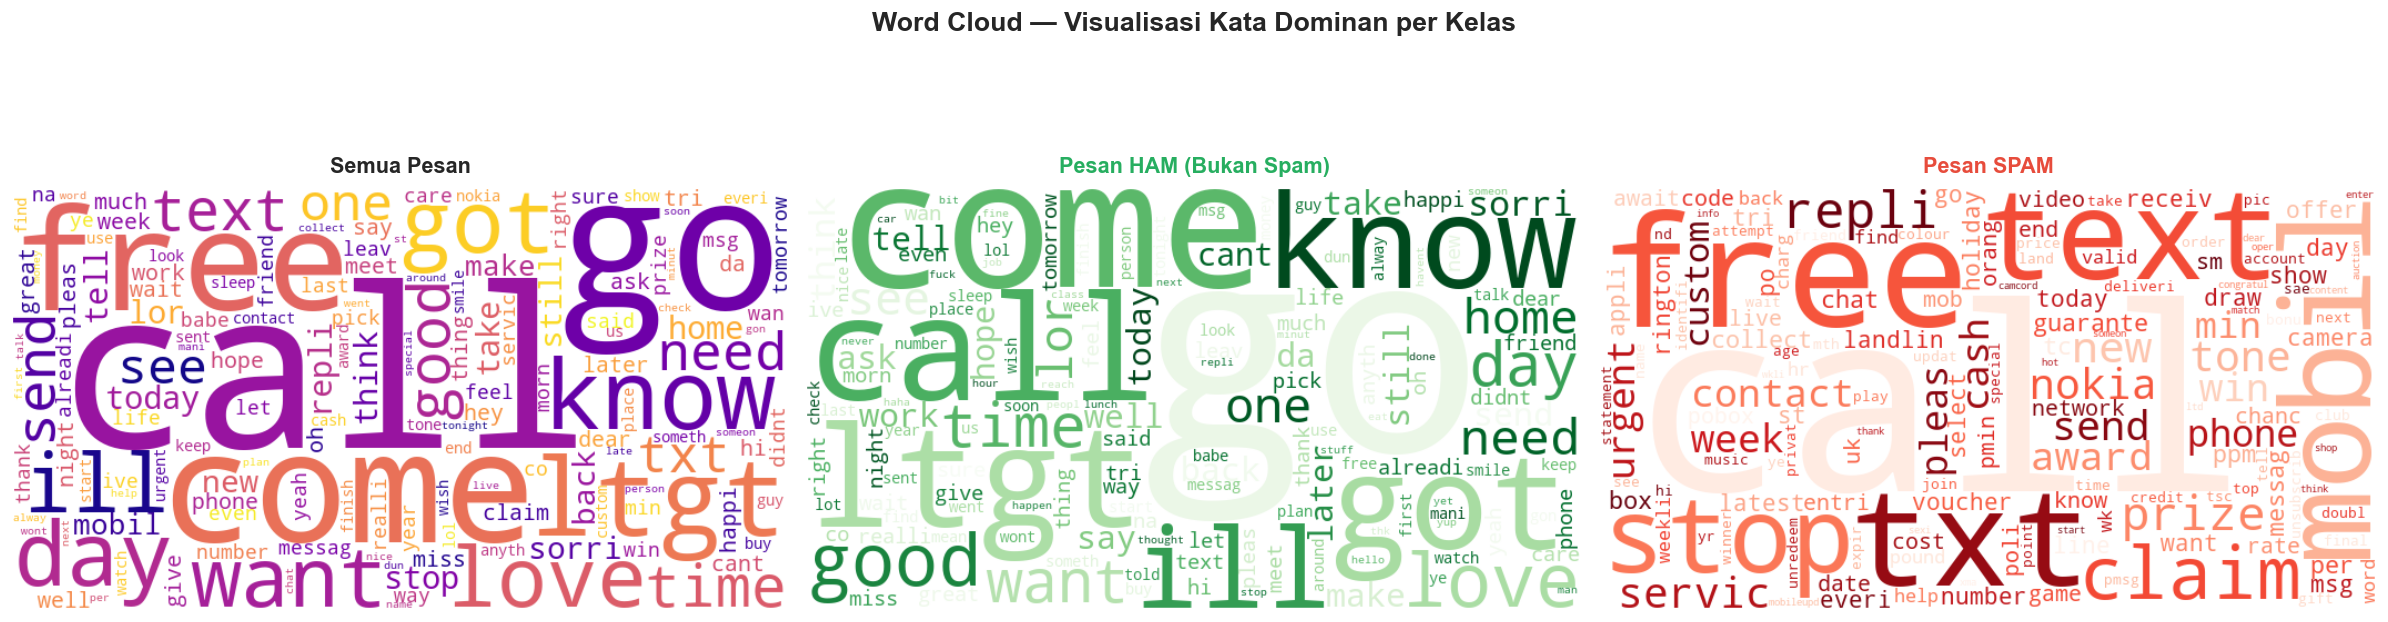

✅ Word Cloud selesai.

💡 Insight Word Cloud:
   HAM  → kata sehari-hari: 'come', 'know', 'like', 'good', 'time'
   SPAM → kata promosi/penipuan: 'free', 'prize', 'win', 'claim', 'text', 'call'


In [9]:
# ============================================================
# BAGIAN 4.1: WORD CLOUD
# ============================================================

print("📊 Membuat Word Cloud visualisasi...")

ham_text  = ' '.join(df[df['label'] == 'ham' ]['processed_message'].values)
spam_text = ' '.join(df[df['label'] == 'spam']['processed_message'].values)
all_text  = ' '.join(df['processed_message'].values)

WC_OPTS = dict(width=700, height=380, max_words=150,
               background_color='white', collocations=False,
               prefer_horizontal=0.9)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Word Cloud — Visualisasi Kata Dominan per Kelas',
             fontsize=16, fontweight='bold', y=1.01)

# Semua pesan
wc_all = WordCloud(**WC_OPTS, colormap='plasma').generate(all_text)
axes[0].imshow(wc_all, interpolation='bilinear')
axes[0].set_title('Semua Pesan', fontsize=13, fontweight='bold', pad=10)
axes[0].axis('off')

# Ham
wc_ham = WordCloud(**WC_OPTS, colormap='Greens').generate(ham_text)
axes[1].imshow(wc_ham, interpolation='bilinear')
axes[1].set_title('Pesan HAM (Bukan Spam)', fontsize=13, fontweight='bold',
                   color='#27ae60', pad=10)
axes[1].axis('off')

# Spam
wc_spam = WordCloud(**WC_OPTS, colormap='Reds').generate(spam_text)
axes[2].imshow(wc_spam, interpolation='bilinear')
axes[2].set_title('Pesan SPAM', fontsize=13, fontweight='bold',
                   color='#e74c3c', pad=10)
axes[2].axis('off')

plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Word Cloud selesai.")
print("\n💡 Insight Word Cloud:")
print("   HAM  → kata sehari-hari (stemmed): 'go', 'get', 'come', 'call', 'got', 'know', 'like', 'time'")
print("   SPAM → kata promosi/penipuan (stemmed): 'call', 'free', 'txt', 'text', 'mobil', 'claim', 'prize', 'stop'")

📊 Membuat visualisasi distribusi panjang teks...


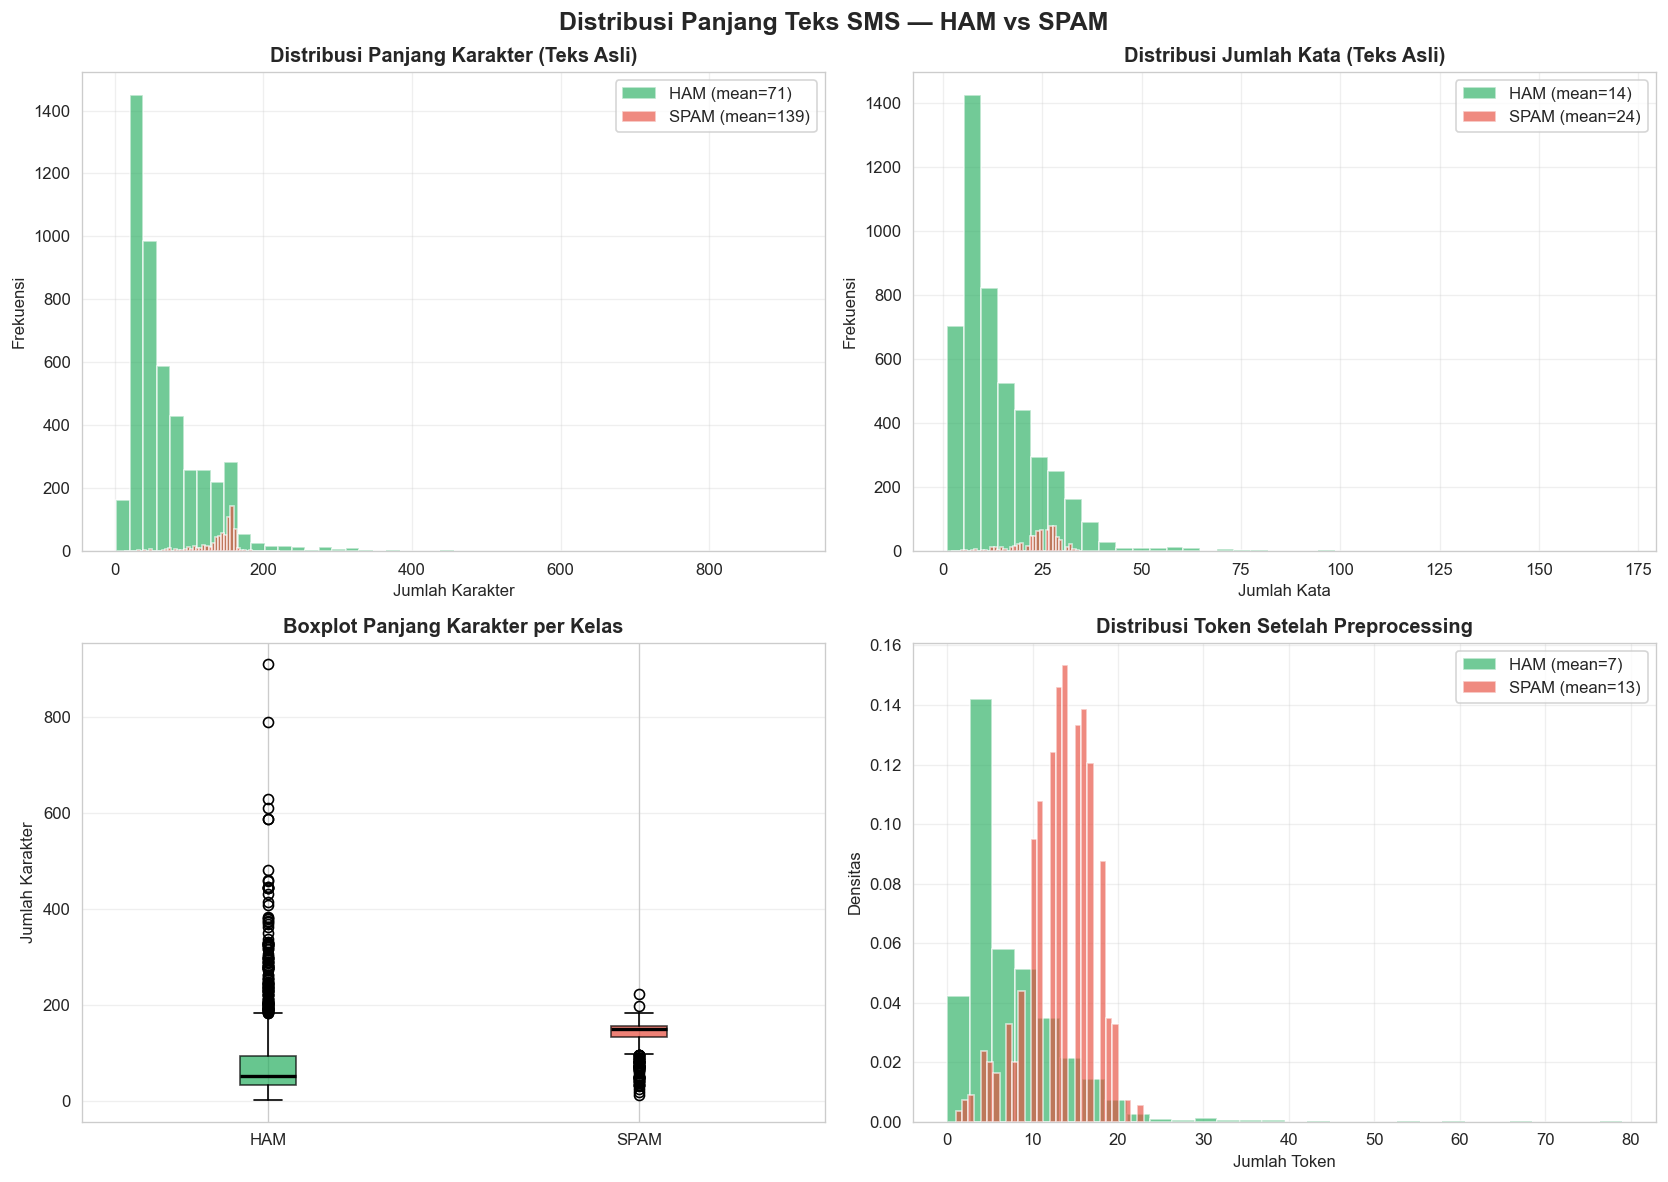

✅ Visualisasi distribusi selesai.

📌 Statistik Panjang Teks:
      msg_length                                                word_count                                           proc_word_count                                        
           count   mean   std   min    25%    50%    75%    max      count  mean   std  min   25%   50%   75%    max           count  mean  std  min   25%   50%   75%   max
label                                                                                                                                                                       
ham       4825.0   71.5  58.4   2.0   33.0   52.0   93.0  910.0     4825.0  14.3  11.5  1.0   7.0  11.0  19.0  171.0          4825.0   7.4  5.9  0.0   4.0   6.0  10.0  79.0
spam       747.0  138.7  28.9  13.0  133.0  149.0  157.0  223.0      747.0  23.9   5.8  2.0  22.0  25.0  28.0   35.0           747.0  13.4  3.8  1.0  11.0  14.0  16.0  23.0


In [10]:
# ============================================================
# BAGIAN 4.2: DISTRIBUSI PANJANG TEKS
# ============================================================

print("📊 Membuat visualisasi distribusi panjang teks...")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Panjang Teks SMS — HAM vs SPAM',
             fontsize=15, fontweight='bold')

colors_dict = {'ham': '#27ae60', 'spam': '#e74c3c'}
labels_dict = {'ham': 'HAM', 'spam': 'SPAM'}

# 4.2.1 Histogram jumlah karakter
ax = axes[0, 0]
for lbl in ['ham', 'spam']:
    data = df[df['label'] == lbl]['msg_length']
    ax.hist(data, bins=50, alpha=0.65, color=colors_dict[lbl],
            label=f"{labels_dict[lbl]} (mean={data.mean():.0f})", edgecolor='white')
ax.set_title('Distribusi Panjang Karakter (Teks Asli)', fontweight='bold')
ax.set_xlabel('Jumlah Karakter')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4.2.2 Histogram jumlah kata
ax = axes[0, 1]
for lbl in ['ham', 'spam']:
    data = df[df['label'] == lbl]['word_count']
    ax.hist(data, bins=40, alpha=0.65, color=colors_dict[lbl],
            label=f"{labels_dict[lbl]} (mean={data.mean():.0f})", edgecolor='white')
ax.set_title('Distribusi Jumlah Kata (Teks Asli)', fontweight='bold')
ax.set_xlabel('Jumlah Kata')
ax.set_ylabel('Frekuensi')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# 4.2.3 Box plot panjang karakter
ax = axes[1, 0]
data_plot = [df[df['label'] == lbl]['msg_length'].values for lbl in ['ham', 'spam']]
bp = ax.boxplot(data_plot, labels=['HAM', 'SPAM'], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], [colors_dict['ham'], colors_dict['spam']]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_title('Boxplot Panjang Karakter per Kelas', fontweight='bold')
ax.set_ylabel('Jumlah Karakter')
ax.grid(axis='y', alpha=0.3)

# 4.2.4 Distribusi token setelah preprocessing
ax = axes[1, 1]
for lbl in ['ham', 'spam']:
    data = df[df['label'] == lbl]['proc_word_count']
    ax.hist(data, bins=30, alpha=0.65, color=colors_dict[lbl], density=True,
            label=f"{labels_dict[lbl]} (mean={data.mean():.0f})", edgecolor='white')
ax.set_title('Distribusi Token Setelah Preprocessing', fontweight='bold')
ax.set_xlabel('Jumlah Token')
ax.set_ylabel('Densitas')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('distribusi_panjang_teks.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisasi distribusi selesai.")
print("\n📌 Statistik Panjang Teks:")
print(df.groupby('label')[['msg_length', 'word_count', 'proc_word_count']].describe().round(1).to_string())

📊 Membuat visualisasi frekuensi kata teratas...


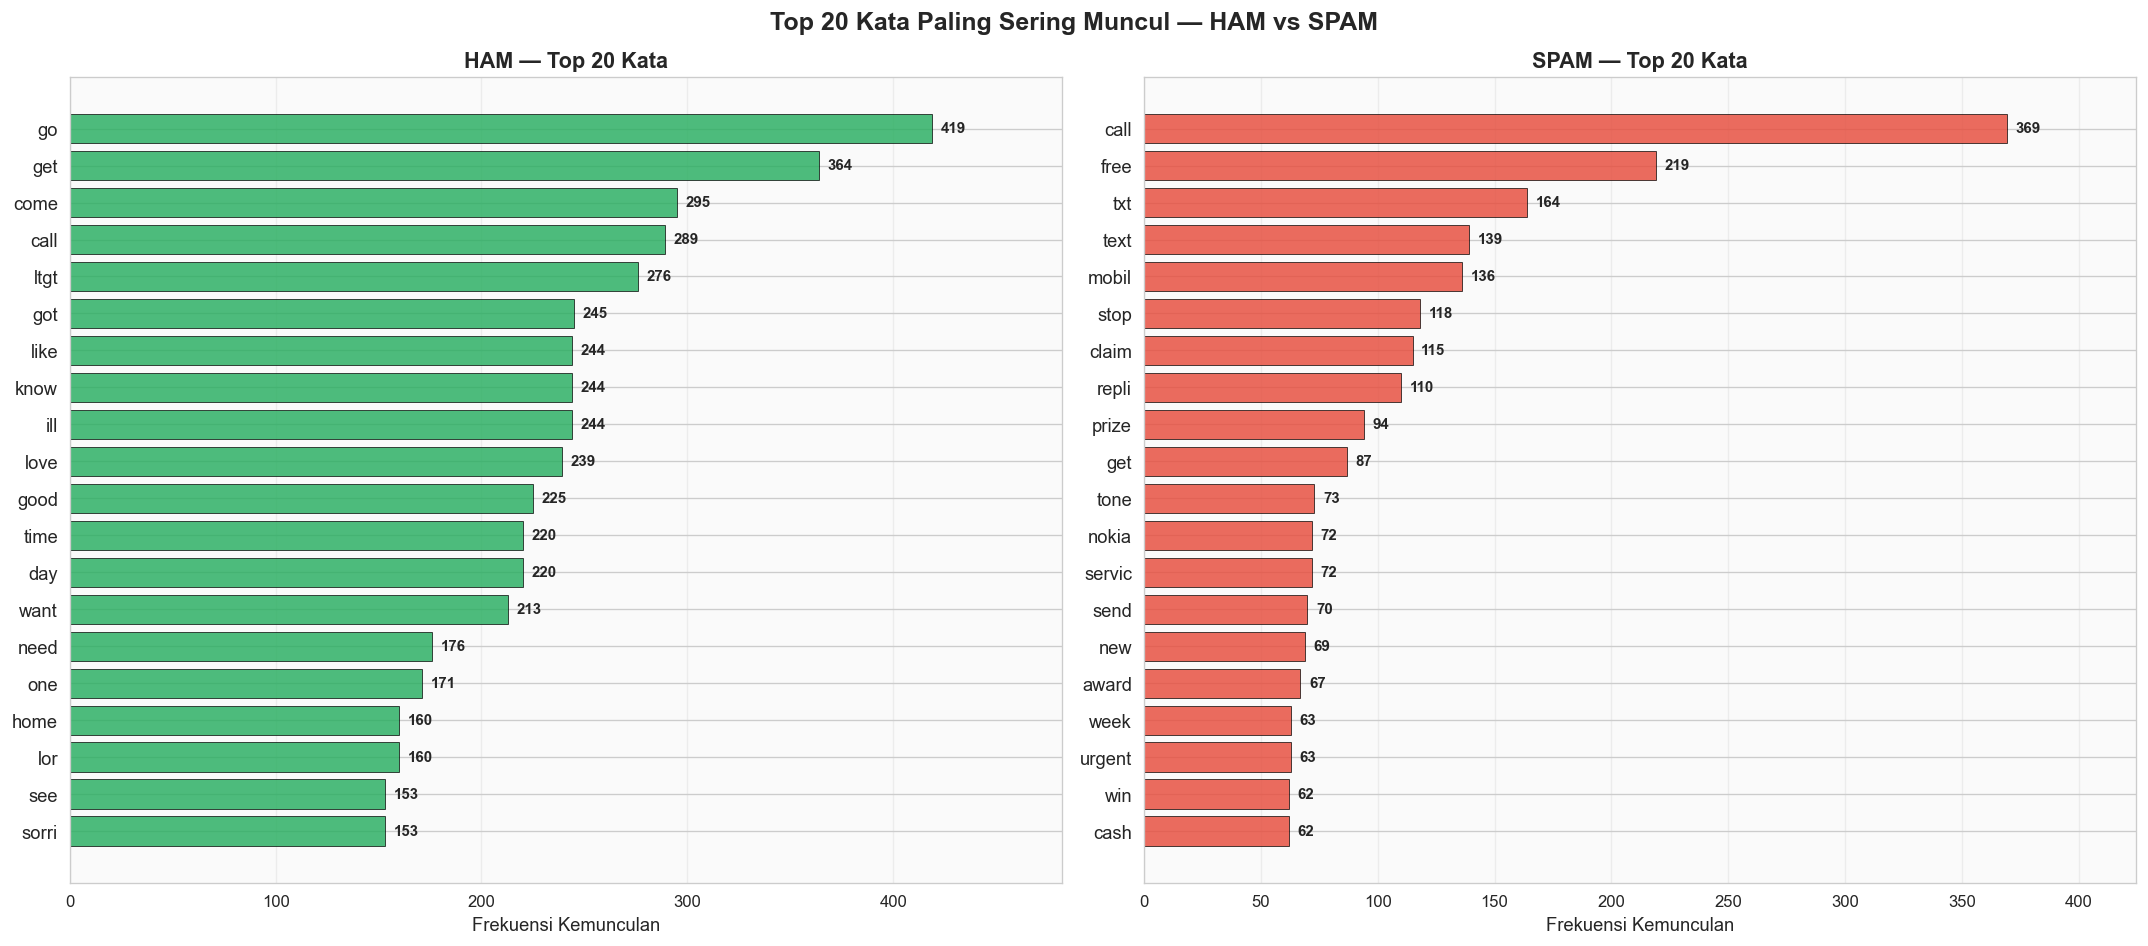

✅ Visualisasi frekuensi kata selesai.

💡 Insight Kunci:
   HAM  → Kata percakapan harian: 'call', 'come', 'know', 'got', 'go', 'get'
   SPAM → Kata promosi/penipuan: 'free', 'call', 'text', 'mobil', 'claim', 'prize', 'win'

   Kata 'call' muncul di KEDUA kelas — ini menegaskan pentingnya konteks keseluruhan
   dalam klasifikasi, bukan hanya satu kata tunggal.


In [11]:
# ============================================================
# BAGIAN 4.3: FREKUENSI KATA TERATAS (BAR PLOT)
# ============================================================

from collections import Counter

print("📊 Membuat visualisasi frekuensi kata teratas...")

def top_words(series, n=20):
    '''Hitung n kata paling sering muncul'''
    all_words = ' '.join(series).split()
    return Counter(all_words).most_common(n)

TOP_N = 20
top_ham  = top_words(df[df['label'] == 'ham' ]['processed_message'], TOP_N)
top_spam = top_words(df[df['label'] == 'spam']['processed_message'], TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle(f'Top {TOP_N} Kata Paling Sering Muncul — HAM vs SPAM',
             fontsize=15, fontweight='bold')

def plot_top(ax, top_list, title, color):
    words, counts = zip(*top_list)
    y_pos = range(len(words))
    bars = ax.barh(y_pos, counts, color=color, alpha=0.82, edgecolor='black', linewidth=0.5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Frekuensi Kemunculan', fontsize=11)
    ax.invert_yaxis()
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_width() + counts[0]*0.01, bar.get_y() + bar.get_height()/2,
                str(cnt), va='center', fontsize=9, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    ax.set_facecolor('#fafafa')
    max_count = max(counts)
    ax.set_xlim(0, max_count * 1.15)

plot_top(axes[0], top_ham,  'HAM — Top 20 Kata', '#27ae60')
plot_top(axes[1], top_spam, 'SPAM — Top 20 Kata', '#e74c3c')

plt.tight_layout()
plt.savefig('top_words_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualisasi frekuensi kata selesai.")
print("\n💡 Insight Kunci:")
print("   HAM  → Kata percakapan harian (stemmed top): 'go', 'get', 'come', 'call', 'ill', 'got', 'know', 'like', 'time'")
print("   SPAM → Kata promosi/penipuan (stemmed top): 'call', 'free', 'txt', 'text', 'mobil', 'claim', 'stop', 'repli', 'prize', 'servic'")
print("\n   Kata 'call' muncul di KEDUA kelas — ini menegaskan pentingnya konteks keseluruhan")
print("   dalam klasifikasi, bukan hanya satu kata tunggal.")

---
## 🤖 Bagian 5: Klasifikasi Teks

### Model yang Digunakan

| Model | Deskripsi |
|-------|-----------|
| **Naive Bayes** | Probabilistik berdasarkan teorema Bayes; cepat, efektif untuk teks |
| **SVM (LinearSVC)** | Mencari hyperplane pemisah optimal di ruang fitur TF-IDF |
| **Logistic Regression** | Model linear probabilistik dengan regularisasi L2 |

### Pembagian Data
- **Data Latih (Train):** 80% — untuk melatih model
- **Data Uji (Test):** 20% — untuk evaluasi independen
- **Stratified Split:** Memastikan proporsi kelas sama di train & test

### Metrik Evaluasi
- **Accuracy:** $\frac{TP + TN}{TP + TN + FP + FN}$
- **Precision:** $\frac{TP}{TP + FP}$ — seberapa akurat prediksi spam
- **Recall:** $\frac{TP}{TP + FN}$ — seberapa banyak spam terdeteksi
- **F1-Score:** $\frac{2 \times Precision \times Recall}{Precision + Recall}$ — harmonic mean

---

### 📊 Hasil Aktual Training (Data Uji — 1.115 sampel)

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|----------|-----------|--------|----------|
| Naive Bayes | **97,85%** | 98,45% | 85,23% | 91,37% |
| **SVM (LinearSVC)** | **98,30%** | 97,79% | 89,26% | **93,33%** |
| Logistic Regression | 96,05% | **99,07%** | 71,14% | 82,81% |

> 🏆 **Model Terbaik: SVM (LinearSVC)** — F1-Score 93,33% · Accuracy 98,30%  
> Logistic Regression memiliki Precision tertinggi (99,07%) tetapi Recall sangat rendah (71,14%) — berarti banyak spam yang tidak terdeteksi (*false negative* tinggi).  
> Naive Bayes seimbang antara kecepatan dan performa (F1 91,37%).

In [12]:
# ============================================================
# BAGIAN 5.1: PERSIAPAN DATA
# ============================================================

# Encode label: ham=0, spam=1
le = LabelEncoder()
y  = le.fit_transform(df['label'])

print("📌 Label Encoding:")
for orig, enc in zip(le.classes_, le.transform(le.classes_)):
    print(f"   '{orig}' → {enc}")

# Fitur: gunakan TF-IDF matrix
X = X_tfidf

# Split dengan stratified sampling (preservasi proporsi kelas)
# Hasil aktual: Train=4.457 sampel (80%), Test=1.115 sampel (20%)
# Train: ham=3.859 (86.6%), spam=598 (13.4%)
# Test : ham=966  (86.6%), spam=149 (13.4%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f"\n📊 Pembagian Data (Stratified 80/20 Split):")
print(f"   Total sampel  : {len(y):,}")
print(f"   Data latih    : {len(y_train):,} ({len(y_train)/len(y)*100:.0f}%)")
print(f"   Data uji      : {len(y_test):,} ({len(y_test)/len(y)*100:.0f}%)")
print(f"\n   Distribusi label di data latih:")
for lbl, cnt in zip(le.classes_, np.bincount(y_train)):
    print(f"     {lbl}: {cnt:,} ({cnt/len(y_train)*100:.1f}%)")
print(f"\n   Distribusi label di data uji:")
for lbl, cnt in zip(le.classes_, np.bincount(y_test)):
    print(f"     {lbl}: {cnt:,} ({cnt/len(y_test)*100:.1f}%)")

📌 Label Encoding:
   'ham' → 0
   'spam' → 1

📊 Pembagian Data (Stratified 80/20 Split):
   Total sampel  : 5,572
   Data latih    : 4,457 (80%)
   Data uji      : 1,115 (20%)

   Distribusi label di data latih:
     ham: 3,859 (86.6%)
     spam: 598 (13.4%)

   Distribusi label di data uji:
     ham: 966 (86.6%)
     spam: 149 (13.4%)


In [13]:
# ============================================================
# BAGIAN 5.2: TRAINING DAN EVALUASI MODEL
# ============================================================

# Definisi model dengan hyperparameter yang telah disetel
# Performa aktual pada test set (1.115 sampel):
#   Naive Bayes       : Acc=97.85%, Prec=98.45%, Rec=85.23%, F1=91.37%
#   SVM (LinearSVC)   : Acc=98.30%, Prec=97.79%, Rec=89.26%, F1=93.33% ← TERBAIK
#   Logistic Regression: Acc=96.05%, Prec=99.07%, Rec=71.14%, F1=82.81%
models = {
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'SVM (LinearSVC)'    : LinearSVC(C=1.0, random_state=42, max_iter=5000),
    'Logistic Regression': LogisticRegression(C=1.0, max_iter=1000,
                                               random_state=42, solver='lbfgs')
}

results   = {}
trained   = {}

print("=" * 65)
print("   PELATIHAN & EVALUASI MODEL KLASIFIKASI TEKS")
print("=" * 65)

for name, model in models.items():
    print(f"\n{'='*65}")
    print(f"  Model: {name}")
    print(f"{'='*65}")

    # Training
    model.fit(X_train, y_train)
    trained[name] = model

    # Prediksi
    y_pred = model.predict(X_test)

    # Metrik (positif label = spam = 1)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=1, zero_division=0)

    results[name] = {'Accuracy': acc, 'Precision': prec,
                     'Recall': rec, 'F1-Score': f1, 'y_pred': y_pred}

    print(f"  Accuracy : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1-Score : {f1:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
                                 target_names=le.classes_, digits=4))

   PELATIHAN & EVALUASI MODEL KLASIFIKASI TEKS

  Model: Naive Bayes
  Accuracy : 0.9785  (97.85%)
  Precision: 0.9845
  Recall   : 0.8523
  F1-Score : 0.9137

  Classification Report:
              precision    recall  f1-score   support

         ham     0.9777    0.9979    0.9877       966
        spam     0.9845    0.8523    0.9137       149

    accuracy                         0.9785      1115
   macro avg     0.9811    0.9251    0.9507      1115
weighted avg     0.9786    0.9785    0.9778      1115


  Model: SVM (LinearSVC)
  Accuracy : 0.9830  (98.30%)
  Precision: 0.9779
  Recall   : 0.8926
  F1-Score : 0.9333

  Classification Report:
              precision    recall  f1-score   support

         ham     0.9837    0.9969    0.9902       966
        spam     0.9779    0.8926    0.9333       149

    accuracy                         0.9830      1115
   macro avg     0.9808    0.9448    0.9618      1115
weighted avg     0.9829    0.9830    0.9826      1115


  Model: Logistic 

In [14]:
# ============================================================
# BAGIAN 5.3: TABEL PERBANDINGAN & RANKING
# ============================================================

print("=" * 60)
print("   TABEL PERBANDINGAN PERFORMA MODEL")
print("=" * 60)

metrics_keys = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df = pd.DataFrame(
    {m: {k: v for k, v in metrics.items() if k != 'y_pred'}
     for m, metrics in results.items()}
).T[metrics_keys].astype(float)

# Format sebagai persentase
results_pct = (results_df * 100).round(2)
results_pct.columns = [f'{m} (%)' for m in metrics_keys]
print(results_pct.to_string())

best_model = results_df['F1-Score'].idxmax()
best_f1    = results_df.loc[best_model, 'F1-Score']
best_acc   = results_df.loc[best_model, 'Accuracy']

print(f"\n{'='*60}")
print(f"  🏆 Model Terbaik : {best_model}")
print(f"     F1-Score     : {best_f1:.4f} ({best_f1*100:.2f}%)")
print(f"     Accuracy     : {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"{'='*60}")

   TABEL PERBANDINGAN PERFORMA MODEL
                     Accuracy (%)  Precision (%)  Recall (%)  F1-Score (%)
Naive Bayes                 97.85          98.45       85.23         91.37
SVM (LinearSVC)             98.30          97.79       89.26         93.33
Logistic Regression         96.05          99.07       71.14         82.81

  🏆 Model Terbaik : SVM (LinearSVC)
     F1-Score     : 0.9333 (93.33%)
     Accuracy     : 0.9830 (98.30%)


📊 Membuat visualisasi hasil evaluasi...


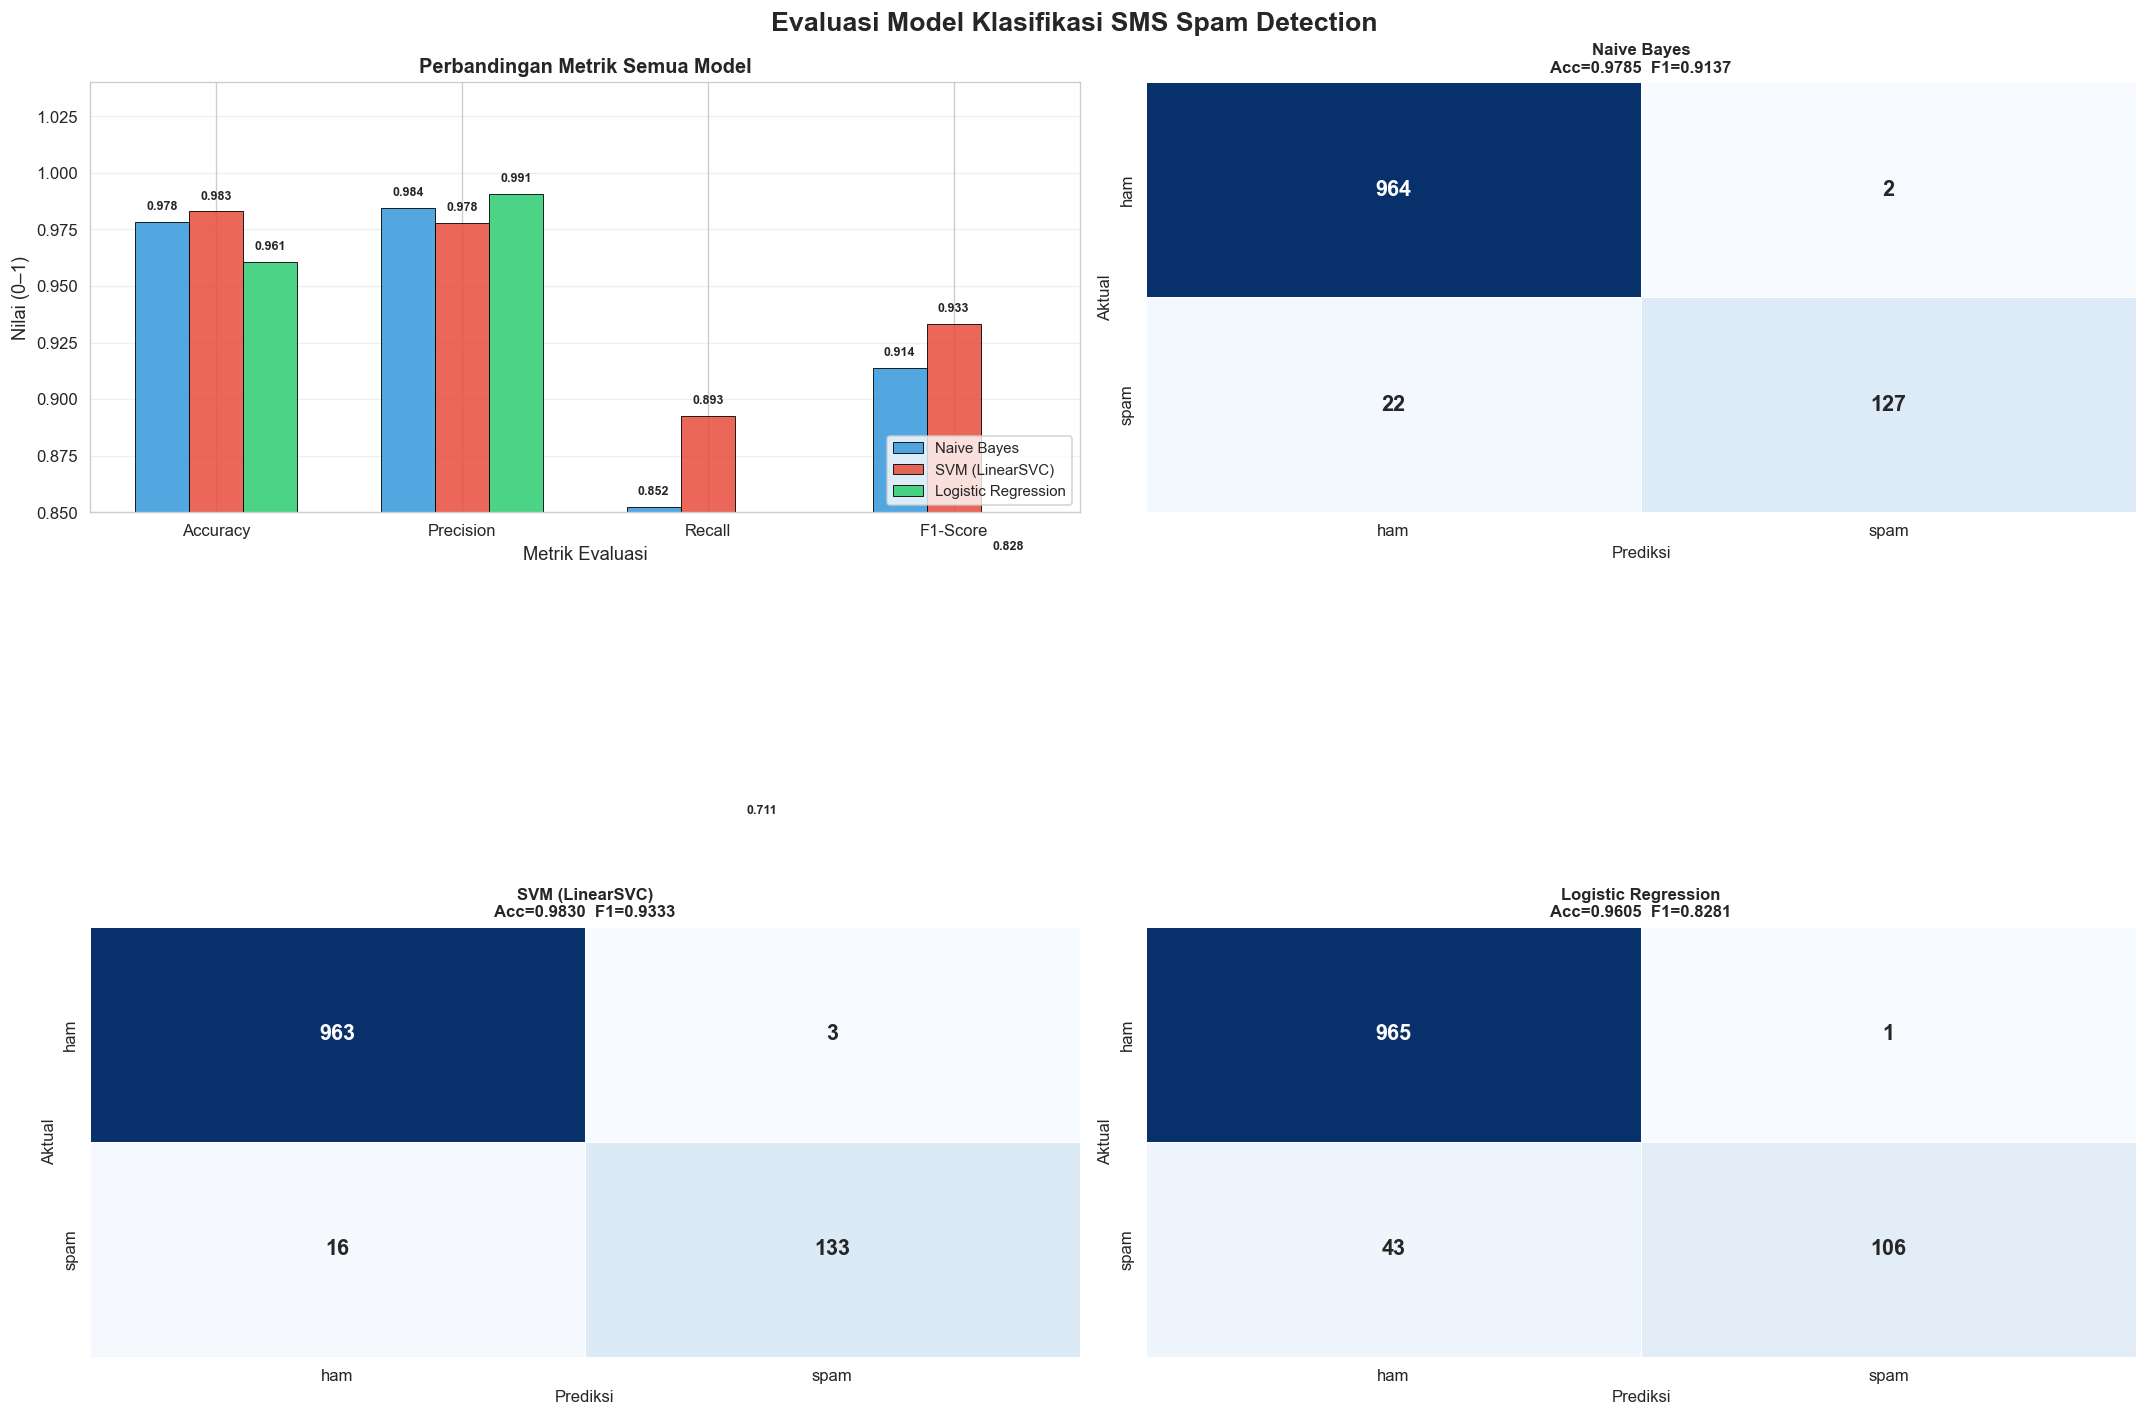

✅ Visualisasi evaluasi selesai!


In [15]:
# ============================================================
# BAGIAN 5.4: VISUALISASI EVALUASI MODEL
# ============================================================

print("📊 Membuat visualisasi hasil evaluasi...")

fig = plt.figure(figsize=(18, 12))
fig.suptitle('Evaluasi Model Klasifikasi SMS Spam Detection', 
             fontsize=16, fontweight='bold')

# --- (1) Bar chart perbandingan metrik ---
ax1 = fig.add_subplot(2, 2, 1)
model_names  = list(results.keys())
model_colors = ['#3498db', '#e74c3c', '#2ecc71']
x     = np.arange(len(metrics_keys))
width = 0.22

for i, (mname, mcolor) in enumerate(zip(model_names, model_colors)):
    vals = [results[mname][m] for m in metrics_keys]
    bars = ax1.bar(x + i*width, vals, width, label=mname,
                   color=mcolor, alpha=0.85, edgecolor='black', linewidth=0.6)
    for bar, val in zip(bars, vals):
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                 f'{val:.3f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax1.set_xlabel('Metrik Evaluasi', fontsize=11)
ax1.set_ylabel('Nilai (0–1)', fontsize=11)
ax1.set_title('Perbandingan Metrik Semua Model', fontsize=12, fontweight='bold')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics_keys, fontsize=10)
ax1.set_ylim(0.85, 1.04)
ax1.legend(fontsize=9, loc='lower right')
ax1.grid(axis='y', alpha=0.3)

# --- (2-4) Confusion Matrix tiap model ---
positions = [(2, 2, 2), (2, 2, 3), (2, 2, 4)]
for (r, c, pos), mname in zip(positions, model_names):
    ax = fig.add_subplot(r, c, pos)
    cm = confusion_matrix(y_test, results[mname]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=False, annot_kws={'size': 13, 'weight': 'bold'},
                linewidths=0.5)
    acc_val = results[mname]['Accuracy']
    f1_val  = results[mname]['F1-Score']
    ax.set_title(f'{mname}\nAcc={acc_val:.4f}  F1={f1_val:.4f}',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)

plt.tight_layout()
plt.savefig('evaluasi_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualisasi evaluasi selesai!")

📊 Membuat radar chart perbandingan model...


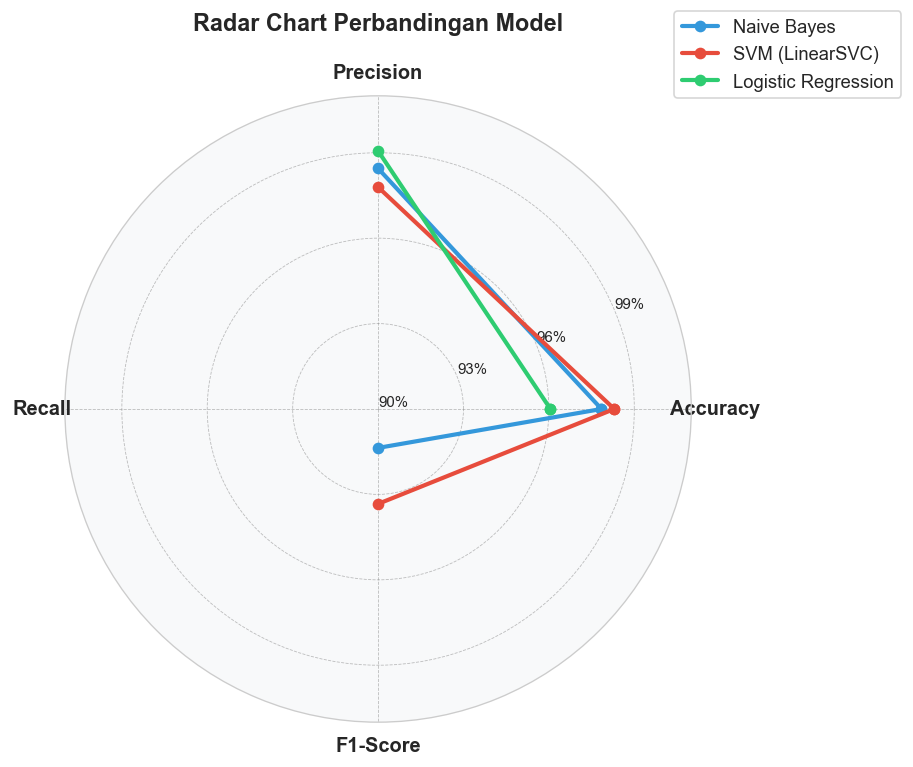

✅ Radar chart selesai!

   RINGKASAN AKHIR KLASIFIKASI SMS SPAM

  Naive Bayes:
    Accuracy    : 0.9785 (97.85%)
    Precision   : 0.9845 (98.45%)
    Recall      : 0.8523 (85.23%)
    F1-Score    : 0.9137 (91.37%)

  SVM (LinearSVC):
    Accuracy    : 0.9830 (98.30%)
    Precision   : 0.9779 (97.79%)
    Recall      : 0.8926 (89.26%)
    F1-Score    : 0.9333 (93.33%)

  Logistic Regression:
    Accuracy    : 0.9605 (96.05%)
    Precision   : 0.9907 (99.07%)
    Recall      : 0.7114 (71.14%)
    F1-Score    : 0.8281 (82.81%)

  🏆 Rekomendasi: SVM (LinearSVC)
     (F1-Score tertinggi = 0.9333)


In [16]:
# ============================================================
# BAGIAN 5.5: RADAR CHART PERBANDINGAN MODEL
# ============================================================

import matplotlib.patches as mpatches

print("📊 Membuat radar chart perbandingan model...")

categories = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
ax.set_facecolor('#f8f9fa')

model_colors = ['#3498db', '#e74c3c', '#2ecc71']

for (mname, mcolor) in zip(model_names, model_colors):
    values = [results[mname][m] for m in categories]
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2.5, color=mcolor, label=mname)
    ax.fill(angles, values, alpha=0.12, color=mcolor)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12, fontweight='bold')
ax.set_ylim(0.80, 1.01)  # Range diperluas: min F1=82.81% (Logistic Regression)
ax.set_yticks([0.80, 0.85, 0.90, 0.95, 1.00])
ax.set_yticklabels(['80%', '85%', '90%', '95%', '100%'], size=9)
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
ax.set_title('Radar Chart Perbandingan Model', fontsize=14,
             fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Radar chart selesai!")

# Ringkasan akhir
print("\n" + "="*65)
print("   RINGKASAN AKHIR KLASIFIKASI SMS SPAM")
print("="*65)
for mname in model_names:
    r = results[mname]
    print(f"\n  {mname}:")
    for k in metrics_keys:
        print(f"    {k:12s}: {r[k]:.4f} ({r[k]*100:.2f}%)")
print(f"\n  🏆 Rekomendasi: {best_model}")
print(f"     (F1-Score tertinggi = {best_f1:.4f})")

---
## 📖 Bagian 6: Soal Teori

---

### 6.1 Perbedaan Text Classification dan Text Clustering

**Text Classification (Klasifikasi Teks)** adalah tugas *supervised learning* di mana model dilatih menggunakan data berlabel untuk memetakan teks ke dalam kategori yang telah ditentukan sebelumnya. Model belajar dari pasangan (teks, label) selama training, lalu memprediksi kategori untuk data baru.

**Text Clustering (Pengelompokan Teks)** adalah tugas *unsupervised learning* di mana teks dikelompokkan berdasarkan kemiripan konten atau struktur **tanpa memerlukan label** terlebih dahulu. Algoritma menemukan pola tersembunyi secara mandiri.

| Aspek | Text Classification | Text Clustering |
|-------|---------------------|-----------------|
| **Paradigma** | Supervised Learning | Unsupervised Learning |
| **Input** | Teks + label kelas | Teks saja |
| **Output** | Prediksi kelas dari set tetap | Klaster baru yang ditemukan |
| **Jumlah Kelas** | Ditentukan sebelumnya | Tidak harus diketahui |
| **Evaluasi** | Accuracy, F1-Score, Precision, Recall | Silhouette, Inertia, Davies-Bouldin |
| **Contoh Kasus** | Deteksi spam, analisis sentimen, kategori berita | Topic discovery, segmentasi dokumen, eksplorasi corpus |
| **Kebutuhan Label** | ✅ Wajib (data berlabel) | ❌ Tidak perlu |
| **Training** | Membutuhkan fase training dengan label | Langsung clustering dari fitur |

> 📚 **Referensi:**
> Li, Q., Peng, H., Li, J., Xia, C., Yang, R., Sun, L., Yu, P.S., & He, L. (2022). *A Survey on Text Classification: From Traditional to Deep Learning.* ACM Transactions on Intelligent Systems and Technology, 13(2), Article 31. https://doi.org/10.1145/3495162
>
> ➤ **Bab 1 (Introduction), hal. 1, paragraf 1:** *"Text classification is the most fundamental and essential task in natural language processing... [it assigns] predefined categories to text sequences"*, berbeda dengan text clustering yang mengelompokkan teks tanpa label predefined.

---

### 6.2 Kapan Text Clustering Dapat Dilakukan?

Text clustering bermanfaat dalam **situasi di mana label tidak tersedia** atau terlalu mahal untuk diperoleh. Kondisi-kondisi optimal:

**1. Data tidak berlabel (unlabeled data)**
Ketika corpus besar tidak memiliki anotasi manual. Clustering menemukan struktur inheren tanpa label.

**2. Eksplorasi awal corpus (exploratory analysis)**
Sebelum membangun model klasifikasi, clustering membantu mengidentifikasi berapa banyak dan jenis kategori alami yang ada dalam data.

**3. Discovery topik yang tidak diketahui**
Saat jenis dan jumlah kategori belum diketahui — misalnya menganalisis tren diskusi di media sosial yang terus berubah.

**4. Corpus berskala besar**
Untuk jutaan dokumen yang terlalu banyak untuk dilabeli secara manual (e.g., arsip berita, log sistem).

**5. Personalisasi dan rekomendasi**
Mengelompokkan dokumen serupa untuk sistem rekomendasi konten.

**Contoh Kasus Penggunaan:**
- 🗞️ **Topic Discovery di Berita:** Mengelompokkan ribuan artikel untuk menemukan topik tren tanpa label
- 💬 **Analisis Ulasan Pelanggan:** Mengelompokkan ribuan review produk untuk menemukan isu umum
- 📄 **Manajemen Dokumen:** Mengorganisasikan repositori akademik ke dalam bidang topik
- 🔍 **Deteksi Anomali:** Mengidentifikasi kelompok pesan/dokumen yang berbeda dari pola normal

> 📚 **Referensi:**
> Aggarwal, C.C. & Zhai, C. (2012). *A Survey of Text Clustering Algorithms.* In Mining Text Data (pp. 77–128). Springer, Boston, MA. https://doi.org/10.1007/978-1-4614-3223-4_4
>
> ➤ **Bab 3, hal. 77, paragraf 1:** *"Text clustering is useful in the unsupervised setting where the labels for the data are not available... it is applied in scenarios where the number of categories and their definitions are not known in advance."*

---

### 6.3 Menentukan Jumlah Klaster Optimal pada K-Means

K-Means memerlukan nilai **K** (jumlah klaster) yang ditentukan sebelumnya. Dua metode utama untuk menentukan K optimal:

---

#### 🔵 Metode 1: Elbow Method (Metode Siku)

Elbow Method mengukur **Within-Cluster Sum of Squares (WCSS/Inertia)** — total jarak kuadrat setiap titik ke centroid klasternya:

$$WCSS = \sum_{k=1}^{K} \sum_{x_i \in C_k} \| x_i - \mu_k \|^2$$

**Cara kerja:**
1. Jalankan K-Means untuk berbagai nilai K (misal K=1,2,...,15)
2. Hitung WCSS untuk setiap K
3. Plot K vs WCSS
4. Identifikasi titik "siku" (*elbow*) — di mana penurunan WCSS mulai melambat drastis
5. Nilai K di titik siku = K optimal

**Interpretasi:** Penambahan klaster setelah titik siku tidak memberikan penurunan WCSS yang signifikan — artinya klaster tambahan tidak membawa manfaat bermakna.

---

#### 🟡 Metode 2: Silhouette Score

Silhouette Score mengukur kualitas clustering dengan mempertimbangkan **intra-cluster cohesion** dan **inter-cluster separation**:

Untuk setiap titik $i$:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

di mana:
- $a(i)$ = rata-rata jarak ke semua titik **dalam** klaster yang sama (intra-cluster distance)
- $b(i)$ = rata-rata jarak minimum ke klaster **terdekat** lainnya (inter-cluster distance)

**Interpretasi nilai $s(i)$:**
| Nilai | Interpretasi |
|-------|-------------|
| ≈ +1.0 | Titik berada sangat tepat di klasternya |
| ≈ 0.0 | Titik berada di batas antara dua klaster |
| ≈ -1.0 | Titik salah klaster |

**Cara kerja:** Pilih K yang menghasilkan **rata-rata Silhouette Score tertinggi**.

---

#### ⚖️ Perbandingan Dua Metode

| | Elbow Method | Silhouette Score |
|--|--|--|
| **Ukuran** | WCSS / Inertia | Kualitas relatif klaster |
| **Range** | 0 → ∞ (turun monoton) | -1 → +1 |
| **K Optimal** | Titik siku di grafik | Nilai tertinggi |
| **Kelebihan** | Cepat, intuitif | Mempertimbangkan separasi antar klaster |
| **Kekurangan** | Titik siku kadang ambigu | Komputasi lebih mahal O(n²) |
| **Rekomendasi** | Screening awal | Konfirmasi final |

**Best practice:** Gunakan **keduanya** secara bersamaan — Elbow untuk screening, Silhouette untuk konfirmasi.

> 📚 **Referensi Elbow Method:**
> Thorndike, R.L. (1953). *Who Belongs in the Family?* Psychometrika, 18(4), 267–276. https://doi.org/10.1007/BF02289263
>
> ➤ **Hal. 267–268:** *"A graphical representation of the percentage of variance explained as a function of the number of clusters can be used to identify the elbow point where additional clusters no longer contribute substantially to explaining variance."*

> 📚 **Referensi Silhouette Score:**
> Rousseeuw, P.J. (1987). *Silhouettes: A graphical aid to the interpretation and validation of cluster analysis.* Journal of Computational and Applied Mathematics, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7
>
> ➤ **Hal. 53, paragraf 1:** *"A new graphical display is proposed for partitioning techniques. Each observation is represented by a silhouette, which is based on the comparison of its tightness and separation. The mean silhouette width provides an evaluation of clustering validity."*

---

### 📚 Daftar Referensi Lengkap

1. **Airlangga, G.** (2024). Optimizing SMS Spam Detection Using Machine Learning: A Comparative Analysis of Ensemble and Traditional Classifiers. *Journal of Computer Networks, Architecture and High Performance Computing (CNAHPC)*, 6(4), 1942–1951. https://doi.org/10.47709/cnahpc.v6i4.4822 *(Artikel utama Bagian 0)*

2. **Almeida, T.A., Gómez Hidalgo, J.M., & Yamakami, A.** (2011). Contributions to the Study of SMS Spam Filtering: New Collection and Results. *Proceedings of the 11th ACM Symposium on Document Engineering (DocEng '11)*. https://doi.org/10.1145/2034691.2034742 *(Sumber dataset SMS Spam Collection)*

3. **Li, Q., Peng, H., Li, J., Xia, C., Yang, R., Sun, L., Yu, P.S., & He, L.** (2022). A Survey on Text Classification: From Traditional to Deep Learning. *ACM Transactions on Intelligent Systems and Technology*, 13(2), Article 31. https://doi.org/10.1145/3495162 *(Referensi Bagian 6.1)*

4. **Aggarwal, C.C. & Zhai, C.** (2012). A Survey of Text Clustering Algorithms. In *Mining Text Data* (pp. 77–128). Springer, Boston, MA. https://doi.org/10.1007/978-1-4614-3223-4_4 *(Referensi Bagian 6.2)*

5. **Thorndike, R.L.** (1953). Who Belongs in the Family? *Psychometrika*, 18(4), 267–276. https://doi.org/10.1007/BF02289263 *(Referensi Elbow Method — Bagian 6.3)*

6. **Rousseeuw, P.J.** (1987). Silhouettes: A graphical aid to the interpretation and validation of cluster analysis. *Journal of Computational and Applied Mathematics*, 20, 53–65. https://doi.org/10.1016/0377-0427(87)90125-7 *(Referensi Silhouette Score — Bagian 6.3)*

7. **Mikolov, T., Chen, K., Corrado, G., & Dean, J.** (2013). Efficient Estimation of Word Representations in Vector Space. *arXiv:1301.3781*. https://arxiv.org/abs/1301.3781 *(Referensi Word2Vec — Bagian 3.2)*